In [2]:
# import all libraries you need here
import pandas as pd
import numpy as np
import pathlib as pl
from sklearn.linear_model import LinearRegression
import scanpy as sc
from scipy.optimize import nnls
from sklearn.metrics import adjusted_rand_score, v_measure_score
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile

# Step 0: Download the data

In [2]:
path_data = pl.Path("/Users/ferdinandunterhuber/Documents/Studium/Master/ML for Genomics/Project 2")

In [3]:
#all_bulkified = pd.read_csv(path_data / "test_bulk.csv",index_col=0)
all_bulkified = pd.read_csv("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/train_data/train_bulk.csv",index_col=0)

#train_adata = sc.read_h5ad(path_data / "train_adata.h5ad")
train_adata = sc.read_h5ad("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/train_data/train_adata.h5ad") #added by sammy
test_adata = sc.read_h5ad("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/test_data/test_adata.h5ad")

In [4]:
print(f"Number of patients to deconvolve: {all_bulkified.shape[1]}")
print(f"Number of genes in dataset: {all_bulkified.shape[0]}")

Number of patients to deconvolve: 12
Number of genes in dataset: 7725


In [5]:
print(f"Number of cells in the train set {train_adata.n_obs}")
for spl in train_adata.obs.Sample.unique():
    print(f"Number of cells for {spl} is {train_adata[train_adata.obs.Sample==spl].n_obs}")

Number of cells in the train set 32374
Number of cells for s1 is 6821
Number of cells for s2 is 4555
Number of cells for s3 is 5166
Number of cells for s4 is 5607
Number of cells for s7 is 4471
Number of cells for s8 is 5754


In [6]:
print(f"There are {train_adata.obs.highLevelType.nunique()} different cell types in the dataset")
print(f"The different cells types are {train_adata.obs.highLevelType.unique().astype(str)}")

print(f"the columns of the observations for train_adata are : {train_adata.obs.columns}")
#print(f"columns of the data are : {train_adata.n_obs}")

There are 9 different cell types in the dataset
The different cells types are ['T' 'B' 'Plasmablast' 'Fibroblast' 'Mast' 'Myeloid' 'NK' 'Myofibroblast'
 'Endothelial']
the columns of the observations for train_adata are : Index(['Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts',
       'total_counts', 'total_counts_mt', 'pct_counts_mt', 'highLevelType',
       'chemo'],
      dtype='object')


In [ ]:
import os
import torch
import numpy as np
import scanpy as sc
from scvi.model import SCVI, SCANVI

# =========================
# 1. Data Preparation
# =========================
print("=== Preparing Data ===")

# Mark datasets so we can separate them later
train_adata.obs["dataset_type"] = "Train"
test_adata.obs["dataset_type"] = "Test"

# Prepare the label column
# Train data gets the actual ground truth, Test data gets "Unknown"
train_adata.obs["label_scANVI"] = train_adata.obs["highLevelType"].astype(str)
test_adata.obs["label_scANVI"] = "Unknown"

# Concatenate to ensure same genes and shared latent space
adata = sc.concat([train_adata, test_adata], label="batch_split", join="outer", merge="same")

# Ensure categorical types
adata.obs["dataset_type"] = adata.obs["dataset_type"].astype("category")
adata.obs["Sample"] = adata.obs["Sample"].astype(str).astype("category")
adata.obs["label_scANVI"] = adata.obs["label_scANVI"].astype("category")

# Compute Highly Variable Genes on the combined dataset
print("Finding highly variable genes...")
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=2000, 
    subset=True, 
    flavor="seurat_v3",
    batch_key="Sample"
)

# =========================
# 2. Model Setup & Training
# =========================
print("=== Training Model ===")

# Define Hyperparameters
hyperparams = {
    "n_latent": 20,
    "n_hidden": 128,
    "n_layers": 2,
    "dropout_rate": 0.2,
}

# Setup AnnData for scVI
# We use the combined object. scVI will see "Unknown" labels for the test set.
SCVI.setup_anndata(
    adata,
    labels_key='label_scANVI',
    batch_key='Sample'
)

# Initialize and Train SCVI (Unsupervised / Representation Learning)
scvi_model = SCVI(
    adata,
    n_latent=hyperparams["n_latent"],
    n_hidden=hyperparams["n_hidden"],
    n_layers=hyperparams["n_layers"],
    dropout_rate=hyperparams["dropout_rate"]
)

scvi_model.train(
    max_epochs=100,
    early_stopping=True,
    early_stopping_patience=5,
    accelerator="mps", # Change to "cuda" or "cpu" if needed
    devices=1
)

# Convert to scANVI (Semi-supervised)
scanvi_model = SCANVI.from_scvi_model(
    scvi_model,
    labels_key="label_scANVI",
    unlabeled_category="Unknown",
    n_samples_per_label=50
)

# Train scANVI
# This refines the latent space using the labels from Train data
scanvi_model.train(
    max_epochs=20,
    early_stopping=True,
    early_stopping_patience=5
)

# =========================
# 3. Prediction
# =========================
print("=== Generating Predictions ===")

# Predict labels for the whole dataset
predictions = scanvi_model.predict(adata)
adata.obs["predicted_type"] = predictions

# Predict probabilities (max probability / confidence)
# softmax=True gives probabilities
prob_df = scanvi_model.predict(adata, soft=True)
adata.obs["prediction_probability"] = prob_df.max(axis=1)
# =========================
# 4. Extract Results & Save CSV
# =========================
import pandas as pd

print("=== Saving Results ===")

# 1. Isolate the Test data (which now has the predictions)
final_test_adata = adata[adata.obs["dataset_type"] == "Test"].copy()

# 2. Create the DataFrame exactly as the starter code expects
# Columns must be ["index", "cluster"]
cluster_labels = pd.DataFrame({
    "index": final_test_adata.obs_names,
    "cluster": final_test_adata.obs["predicted_type"]
})

# 3. Check format (Optional, just to be safe)
print("Preview of submission file:")
print(cluster_labels.head())

# 4. Save to CSV
# We use index=False because we manually created the "index" column above
cluster_labels.to_csv("cluster_membership.csv", index=False)

print("Saved 'cluster_membership.csv' successfully.")

# Optional: Save results
# final_test_adata.obs.to_csv("test_set_predictions.csv")

In [7]:
print(f"Number of cells in the test set {test_adata.n_obs}")
for spl in test_adata.obs.Sample.unique():
    print(f"Number of cells for {spl} is {test_adata[test_adata.obs.Sample==spl].n_obs}")
#print(test_adata.var_names)
print(test_adata.obs.columns)


Number of cells in the test set 18616
Number of cells for s5 is 6020
Number of cells for s6 is 5530
Number of cells for s9 is 3336
Number of cells for s10 is 3730
Index(['Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts',
       'total_counts', 'total_counts_mt', 'pct_counts_mt', 'chemo'],
      dtype='object')


# Step 1: Deconvolve the data

In [13]:

# all_bulkified currently points to train bulk (for local evaluation)
all_bulkified = pd.read_csv("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/train_data/train_bulk.csv", index_col=0)
train_adata = sc.read_h5ad("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/train_data/train_adata.h5ad")
test_adata  = sc.read_h5ad("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/test_data/test_adata.h5ad")

test_bulk = pd.read_csv("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/test_data/test_bulk.csv", index_col=0)

train_true_props = pd.read_csv("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/train_data/train_bulk_trueprops.csv", index_col=0)


#  define a decon fct
def run_deconv(mean_ref, ref_total_normalized, bulk_total_normalized,
               ref_log_transform, bulk_log_transform, bulk_df,
               ridge_lambda=0.01, top_n_markers=200):
    ad_ref = train_adata.copy()   # reference built from training single-cell adata
    # Preprocess reference
    if ref_total_normalized:
        sc.pp.normalize_total(ad_ref, target_sum=1e4, inplace=True, max_fraction=1)
    if ref_log_transform:
        sc.pp.log1p(ad_ref)

    # build mean reference per cell type
    norm_ref = {}
    for cell_type in ad_ref.obs['highLevelType'].unique():
        mask = ad_ref.obs['highLevelType'] == cell_type
        X = ad_ref[mask].X
        mean_vec = np.asarray(X.mean(axis=0)).ravel()
        norm_ref[cell_type] = mean_vec
    ref_pd = pd.DataFrame(norm_ref, index=ad_ref.var_names)

    # marker selection (fold-change vs others)
    eps = 1e-9
    markers = set()
    for ct in ref_pd.columns:
        this = ref_pd[ct] + eps
        others = ref_pd.drop(columns=ct).mean(axis=1) + eps
        fc = this / others
        top = fc.nlargest(top_n_markers).index.tolist()
        markers.update(top)
    markers = sorted([g for g in markers if g in ref_pd.index])

    # prepare bulk (bulk_df expected genes x samples)
    df = bulk_df.copy()
    adata = sc.AnnData(df.T)  # samples x genes
    if bulk_total_normalized:
        sc.pp.normalize_total(adata, target_sum=1e4, inplace=True, max_fraction=1)
    # Important: do NOT log bulk when doing NNLS against non-logged ref
    if bulk_log_transform:
        print("Warning: bulk_log_transform=True — ensure reference was log-transformed consistently.")

    bulk_mat = pd.DataFrame(np.asarray(adata.X).T, index=df.index, columns=df.columns)

    # align genes and restrict to markers
    common = ref_pd.index.intersection(bulk_mat.index).intersection(markers)
    if len(common) == 0:
        raise ValueError("No common marker genes between reference and bulk")
    ref_sub = ref_pd.loc[common]
    bulk_sub = bulk_mat.loc[common]

    # scale genes to avoid domination by highly expressed genes
    A = ref_sub.values.astype(float)   # genes x cell_types
    B = bulk_sub.values                 # genes x samples
    gene_norms = np.linalg.norm(A, axis=1, keepdims=True)
    gene_norms[gene_norms == 0] = 1.0
    A_scaled = A / gene_norms
    B_scaled = B / gene_norms

    # NNLS per sample with optional ridge (via augmentation)
    k = A_scaled.shape[1]
    props = np.zeros((k, B_scaled.shape[1]))
    for j in range(B_scaled.shape[1]):
        y = B_scaled[:, j].astype(float)
        if ridge_lambda and ridge_lambda > 0.0:
            lam_sqrt = np.sqrt(ridge_lambda)
            A_aug = np.vstack([A_scaled, lam_sqrt * np.eye(k)])
            y_aug = np.concatenate([y, np.zeros(k)])
            coef, _ = nnls(A_aug, y_aug)
        else:
            coef, _ = nnls(A_scaled, y)
        if coef.sum() > 0:
            coef = coef / coef.sum()
        props[:, j] = coef

    cell_types = ref_sub.columns.tolist()
    pred_props = pd.DataFrame(props, index=cell_types, columns=bulk_sub.columns)

    # If bulk_df is the training bulk, compute RMSE against train_true_props for local debugging
    global_rmse = None
    if set(pred_props.columns).issubset(set(train_true_props.columns)):
        # align rows/cols then compute RMSE
        common_idx = pred_props.index.intersection(train_true_props.index)
        common_cols = pred_props.columns.intersection(train_true_props.columns)
        pp = pred_props.loc[common_idx, common_cols]
        tf = train_true_props.loc[common_idx, common_cols]
        global_rmse = np.sqrt(((pp - tf) ** 2).values.mean())

    return global_rmse, pred_props



# 1) Local evaluation on training bulk
rmse_train, pred_props_train = run_deconv(
    mean_ref=True,
    ref_total_normalized=False,
    bulk_total_normalized=False,
    ref_log_transform=False,
    bulk_log_transform=False,
    bulk_df=all_bulkified
)
print("Train RMSE (local):", rmse_train)

# 2) Final predictions on test bulk (what you must submit)
_, pred_props_test = run_deconv(
    mean_ref=True,
    ref_total_normalized=False,
    bulk_total_normalized=False,
    ref_log_transform=False,
    bulk_log_transform=False,
    bulk_df=test_bulk
)


# correct row order & format
required_ct_order = [
    'T', 'Endothelial', 'Fibroblast', 'Plasmablast',
    'B', 'Myofibroblast', 'NK', 'Myeloid', 'Mast'
]

# Try to reindex pred_props_test to the required ordering
pred = pred_props_test.copy()

# Do we need remapping???
mapping = {
    # 'T cells': 'T',    # uncomment if needed
    # 'Fibroblasts': 'Fibroblast',
    
}
pred.index = [mapping.get(x, x) for x in pred.index]

pred = pred.reindex(required_ct_order)
if pred.isnull().any().any():
    missing = pred[pred.isnull().any(axis=1)]
    raise ValueError(f"Missing cell types after reindexing. Missing rows: {list(missing.index)}")

# Normalize columns robustly to sum to 1
pred = pred.div(pred.sum(axis=0), axis=1).fillna(0)

# Prepare final DataFrame: first column "index", then bulk sample columns (test_bulk sample order)
pred_props_for_save = pred.reset_index().rename(columns={'index':'index'})
pred_props_for_save = pred_props_for_save[['index'] + list(test_bulk.columns)]

# check sums with tolerance
col_sums = pred.sum(axis=0).values
assert np.allclose(col_sums, 1.0, atol=1e-6), "Columns must sum to 1 (within tolerance)"


pred_props_for_save.to_csv("pred_props.csv", index=False)
print("pred_props.csv saved (for submission).")




Train RMSE (local): 0.0774230651673323
pred_props.csv saved (for submission).


# Step 2: Perform clustering 

Leiden and igraph imported successfully!
--- Processing Training Data ---
Ground truth cell types found: ['T', 'B', 'Plasmablast', 'Fibroblast', 'Mast', 'Myeloid', 'NK', 'Myofibroblast', 'Endothelial']


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-11-26 08:55:04,818 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


🔄 Applying HARMONY batch correction using key: 'Sample'...


2025-11-26 08:55:07,249 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-26 08:55:07,326 - harmonypy - INFO - Iteration 1 of 10
2025-11-26 08:55:11,691 - harmonypy - INFO - Iteration 2 of 10
2025-11-26 08:55:15,980 - harmonypy - INFO - Iteration 3 of 10
2025-11-26 08:55:20,405 - harmonypy - INFO - Converged after 3 iterations



🔍 Starting Grid Search (Metrics + Resolutions)...

--- Testing Distance Metric: EUCLIDEAN ---


/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/zq/9vmc9tbn5pv_0b8_c7ffd6nh0000gn/T/ipykernel_91644/595147357.py:87: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ta, resolution=res, key_added=key_name)


   Metric=euclidean, Res=0.10 -> Clusters=7 -> Score=0.7893
   Metric=euclidean, Res=0.15 -> Clusters=7 -> Score=0.7888
   Metric=euclidean, Res=0.20 -> Clusters=7 -> Score=0.7913

--- Testing Distance Metric: COSINE ---


KeyboardInterrupt: 

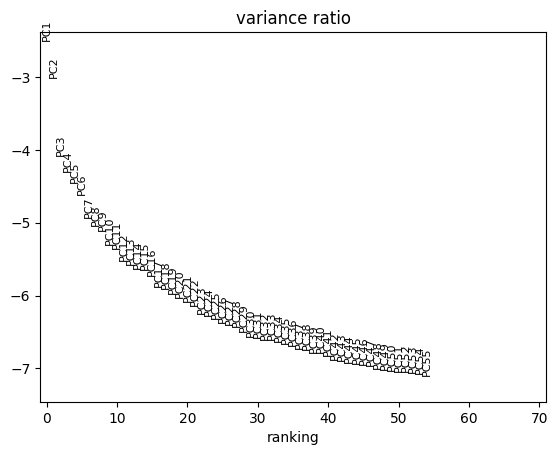

In [9]:

import leidenalg
import igraph

print("Leiden and igraph imported successfully!")
# Eulicdean or Cosine

# train_adata = sc.read_h5ad('train_data.h5ad')
# test_adata = sc.read_h5ad('test_data.h5ad')

# =====================================================
# 1. Processing TRAIN data
# =====================================================
print("--- Processing Training Data ---")
ta = train_adata.copy()

# Ensure highLevelType is categorical for scoring
if 'highLevelType' in ta.obs:
    ta.obs['highLevelType'] = ta.obs['highLevelType'].astype('category')
    print(f"Ground truth cell types found: {ta.obs['highLevelType'].unique().tolist()}")

# QC + HVGs
sc.pp.calculate_qc_metrics(ta, inplace=True)

# STRATEGY 1: Increase HVGs
target_genes = 3000
sc.pp.highly_variable_genes(ta, n_top_genes=target_genes, flavor='seurat_v3')


ta = ta[:, ta.var['highly_variable']].copy()

# Regression + scaling
sc.pp.regress_out(ta, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(ta, max_value=10)

# PCA
sc.tl.pca(ta, n_comps=55)

# -----------------------------------------------------
# NEW: ELBOW PLOT GENERATION
# -----------------------------------------------------

sc.pl.pca_variance_ratio(ta, n_pcs=70, log=True, show=False)
plt.savefig("pca_variance_ratio_elbow.png")

# =====================================================
# 2. Batch Correction (Harmony)
# =====================================================
batch_key = 'Sample'
use_harmony = False

#können diese lines auch kürzen, ist nur zwischendrin schön gewesen für feedback
if batch_key in ta.obs and ta.obs[batch_key].nunique() > 1:
    print(f"🔄 Applying HARMONY batch correction using key: '{batch_key}'...")
    sc.external.pp.harmony_integrate(ta, key=batch_key, basis='X_pca', adjusted_basis='X_pca_harmony')
    use_harmony = True
else:
    print(f"ℹ️ Standard clustering (Batch key '{batch_key}' not found or only 1 batch).")

# =====================================================
# 3. Grid Search: Metric (Euclidean/Cosine) + Resolution
# =====================================================
metrics_to_test = ['euclidean', 'cosine']
resolutions = [0.1, 0.15, 0.2] 
true_labels = ta.obs['highLevelType'].astype(str)

best_score = -1
best_params = {
    'metric': 'euclidean',
    'resolution': resolutions[0]
}

results = [] 

print("\n🔍 Starting Grid Search (Metrics + Resolutions)...")

for metric in metrics_to_test:
    print(f"\n--- Testing Distance Metric: {metric.upper()} ---")
    
    if use_harmony:
        sc.pp.neighbors(ta, n_neighbors=12, n_pcs=55, use_rep='X_pca_harmony', metric=metric)
    else:
        sc.pp.neighbors(ta, n_neighbors=15, n_pcs=50, metric=metric) #Fallback, falls kein Harmony verwendet

    for res in resolutions:
        # Run Leiden
        key_name = f'leiden_{metric}_{res}'
        sc.tl.leiden(ta, resolution=res, key_added=key_name)
        
        # Evaluate
        pred = ta.obs[key_name].astype(str)
        n_clusters = len(ta.obs[key_name].unique())
        
        ari = adjusted_rand_score(true_labels, pred)
        v = v_measure_score(true_labels, pred)
        score = 0.5 * ari + 0.5 * v

        print(f"   Metric={metric}, Res={res:.2f} -> Clusters={n_clusters} -> Score={score:.4f}")
        results.append([metric, res, n_clusters, ari, v, score])

        if score > best_score:
            best_score = score
            best_params['metric'] = metric
            best_params['resolution'] = res

print(f"\n Final choice:")
print(f"   Metric: {best_params['metric']}")
print(f"   Resolution: {best_params['resolution']}")
print(f"   Score: {best_score:.4f}")

# Save grid search results
df_grid = pd.DataFrame(results, columns=["metric", "resolution", "n_clusters", "ARI", "V_measure", "score"])
#df_grid.to_csv("training_clustering_gridsearch.csv", index=False)

# Save best parameters
with open("best_params.txt", "w") as f:
    f.write(f"Metric: {best_params['metric']}\nResolution: {best_params['resolution']}")

# =====================================================
# 4. Finalize TRAIN Model with Best Params
# =====================================================
# Re-run neighbors with best metric
if use_harmony:
    sc.pp.neighbors(ta, n_neighbors=12, n_pcs=55, use_rep='X_pca_harmony', metric=best_params['metric'])
else:
    sc.pp.neighbors(ta, n_neighbors=15, n_pcs=50, metric=best_params['metric'])

# Re-run Leiden with best resolution
sc.tl.leiden(ta, resolution=best_params['resolution'])
ta.obs['best_cluster'] = ta.obs['leiden'].astype(int)

# Final Scores
pred_final = ta.obs['leiden'].astype(str)
ari_final = adjusted_rand_score(true_labels, pred_final)
v_final = v_measure_score(true_labels, pred_final)
final_score = 0.5 * ari_final + 0.5 * v_final

print("\n📈 Final clustering evaluation on training set:")
print(f"ARI       = {ari_final:.4f}")
print(f"V-measure = {v_final:.4f}")

# Save outputs
cluster_df = pd.DataFrame({
    "cell_id": ta.obs_names,
    "cluster": ta.obs["best_cluster"].values
})
#cluster_df.to_csv("train_cluster_assignments.csv", index=False)

# UMAP
sc.tl.umap(ta)
sc.pl.umap(ta, color=['highLevelType', 'leiden', batch_key], legend_loc='on data', show=False)
plt.savefig("umap_train_clusters.png")

# =====================================================
# 5. Apply to TEST set (Submission Generation)
# =====================================================
print(f"\n--- Clustering TEST set using Best Metric ({best_params['metric']}) & Resolution ({best_params['resolution']}) ---")

# Preprocessing Test
ta_test = test_adata.copy()

# QC + HVGs
sc.pp.calculate_qc_metrics(ta_test, inplace=True)

# Ich würde hier auch nur die high variable genes verwenden. Im zweiten Clustering Block werden exact die selben Gene im Test verwendet, wie im Training
target_genes = 3000
sc.pp.highly_variable_genes(ta_test, n_top_genes=target_genes, flavor='seurat_v3')


ta_test = ta_test[:, ta_test.var['highly_variable']].copy()

# Regression + scaling
sc.pp.regress_out(ta_test, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(ta_test, max_value=10)

# PCA&Normalization
#sc.pp.normalize_total(ta_test, target_sum=1e4)
#sc.pp.log1p(ta_test)
sc.tl.pca(ta_test, n_comps=55)

# Apply Harmony to Test
if batch_key in ta_test.obs and ta_test.obs[batch_key].nunique() > 1:
    print(f"🔄 Applying HARMONY to Test Data...")
    sc.external.pp.harmony_integrate(ta_test, key=batch_key, basis='X_pca', adjusted_basis='X_pca_harmony')
    
    # Use BEST METRIC here
    sc.pp.neighbors(ta_test, n_neighbors=12, use_rep='X_pca_harmony', metric=best_params['metric'])
else:
    print("ℹ️ Standard neighbors for Test Data.")
    sc.pp.neighbors(ta_test, n_neighbors=10, use_rep='X_pca', metric=best_params['metric'])

sc.tl.umap(ta_test)

# Use BEST RESOLUTION here
sc.tl.leiden(ta_test, resolution=best_params['resolution'])

# Submission
cluster_labels = pd.DataFrame({
    "index": ta_test.obs_names, #ich weiß nicht, ob hier ein index (0-indexiert) verwendet werden soll. Aber die Tests laufen gut durch
    "cluster": ta_test.obs["leiden"].astype(int).values + 1
})

print("Test set cluster counts:\n", ta_test.obs['leiden'].value_counts())
sc.pl.umap(ta_test, color='leiden', legend_loc='on data', show=False)
plt.savefig("umap_test_clusters.png")

cluster_labels.to_csv("cluster_membership.csv", index=False)
print("\n✅ cluster_membership.csv saved successfully.")

# Step 2b: Predict on the test data

## First Presentation Approach

/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/anndata/_core/merge.py:1666: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


AnnData object with n_obs × n_vars = 32374 × 7725
    obs: 'Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'highLevelType', 'chemo'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/preprocessing/_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


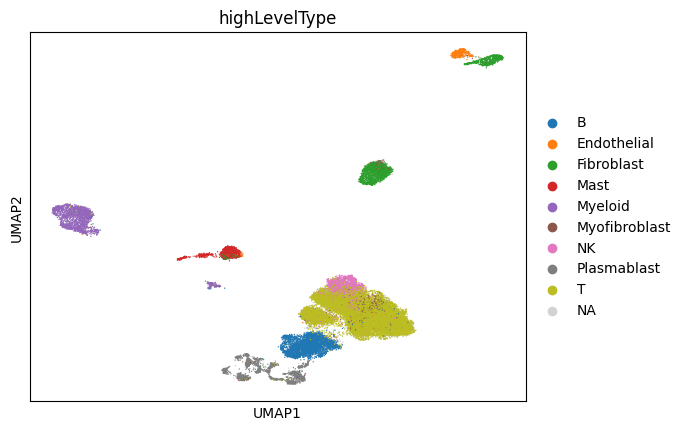

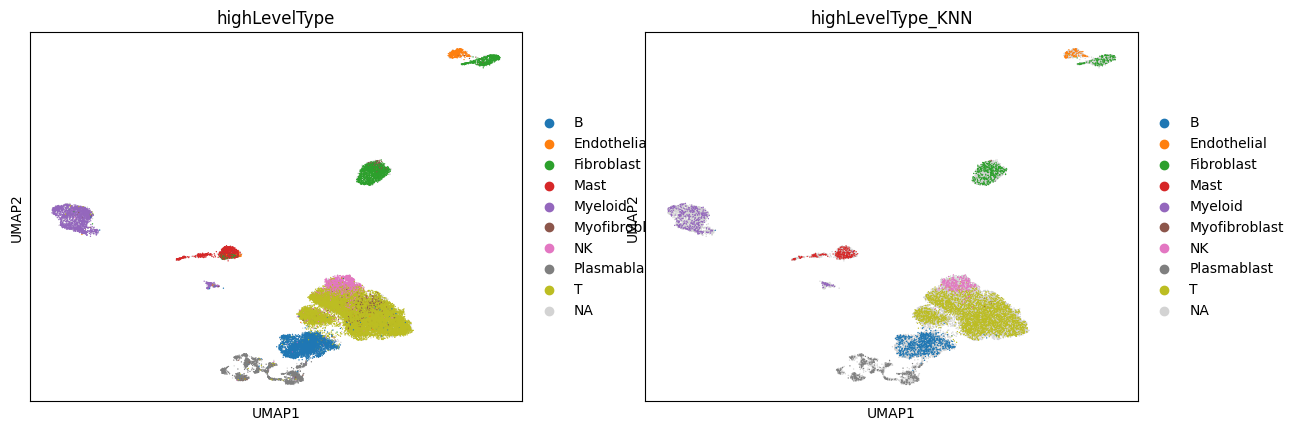

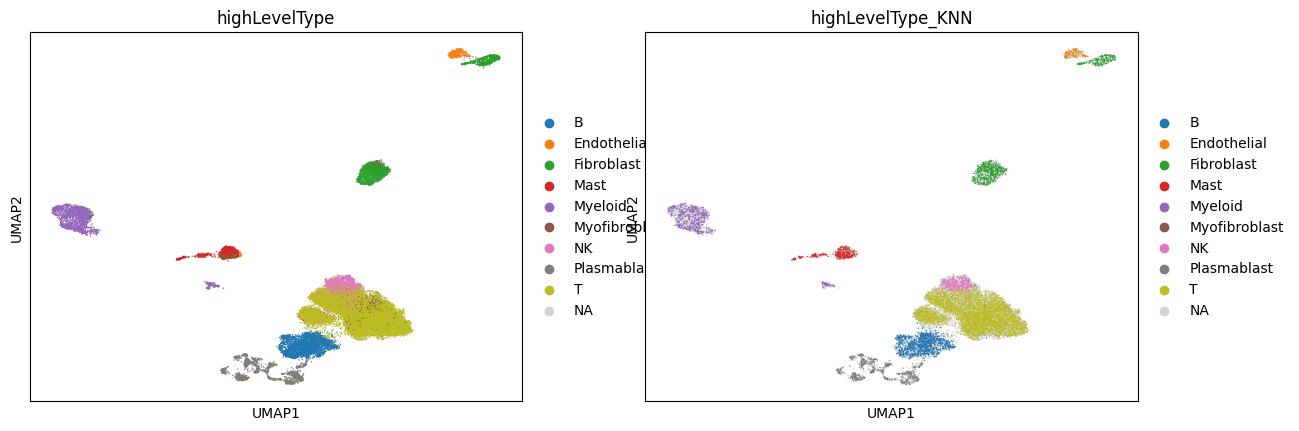


✅ Successfully generated cluster_membership.csv with 6475 test cell assignments.

--- First 5 rows of the generated cluster_membership.csv ---
                  index  cluster
0  TCCTGCACATGTCTAG-1_3       58
1  AAACCCACAAGCGAGT-1_3       52
2  TTACAGGTCGACTCCT-1_8       58
3  TGCTCGTAGAGTCTGG-1_4       58
4  CGTAATGAGACTTCAC-1_7       52

🏆 CLUSTERING/CLASSIFICATION PERFORMANCE
Adjusted Rand Index (ARI): 0.8690
V-Measure Score (V):       0.8431
------------------------------
FINAL SCORE (0.5*ARI + 0.5*V): 0.8561


In [21]:
##slides approach
from sklearn.model_selection import train_test_split
all_cells = train_adata.obs_names.to_list()
train_cells, test_cells  = train_test_split(all_cells, test_size=0.2, random_state=10)
s_adata_train = train_adata[train_cells, :].copy()
s_adata_test = train_adata[test_cells, :].copy()
true_labels = s_adata_test.obs["highLevelType"].copy()

s_adata_test.obs["highLevelType"] = np.nan


import anndata as ad
test_adata.obs["highLevelType"]= np.nan
merged_adata = ad.concat([s_adata_train, s_adata_test], axis = 0, join = "outer", merge="first")
print(merged_adata)

sc.pp.filter_cells(merged_adata, min_genes=100)

sc.pp.filter_genes(merged_adata, min_cells=50)

sc.pp.normalize_total(merged_adata)

sc.pp.log1p(merged_adata)

sc.pp.highly_variable_genes(merged_adata, n_top_genes=400,batch_key="Sample")

# Ensure this is comprehensive:
sc.pp.combat(merged_adata, key='Sample')

sc.tl.pca(merged_adata, n_comps=75)

sc.pp.neighbors(merged_adata, n_neighbors=50)
sc.tl.umap(merged_adata)

sc.pl.umap(merged_adata, color="highLevelType")



from sklearn.neighbors import KNeighborsClassifier
#prepare the data for KNN classification
labeled_cells = merged_adata.obs["highLevelType"].notna() #this is the bitmask
Train_X = merged_adata[labeled_cells].obsm["X_pca"]
Train_y = merged_adata[labeled_cells].obs["highLevelType"]
Test_X = merged_adata[~labeled_cells].obsm["X_pca"]
#initialize the classifier
myclassifier = KNeighborsClassifier(n_neighbors=20)
myclassifier.fit(Train_X, Train_y)
predicted_cell_types = myclassifier.predict(Test_X)
#back into the data
test_cell_indices = merged_adata.obs_names[~labeled_cells]
merged_adata.obs.loc[test_cell_indices, "highLevelType_KNN"] = predicted_cell_types
sc.pl.umap(
    merged_adata,
    color=['highLevelType', 'highLevelType_KNN']
)

progres_index = 0
# --- kNN Classification (Label Transfer) ---
labeled_cells = merged_adata.obs["highLevelType"].notna()
Train_X = merged_adata[labeled_cells].obsm["X_pca"]
Train_y = merged_adata[labeled_cells].obs["highLevelType"]
Test_X = merged_adata[~labeled_cells].obsm["X_pca"]

myclassifier = KNeighborsClassifier(n_neighbors=50)
myclassifier.fit(Train_X, Train_y)
predicted_cell_types = myclassifier.predict(Test_X)

test_cell_indices = merged_adata.obs_names[~labeled_cells]
merged_adata.obs.loc[test_cell_indices, "highLevelType_KNN"] = predicted_cell_types

# UMAP visualization of results (now fixed the case to KNN)
sc.pl.umap(
    merged_adata,
    color=['highLevelType', 'highLevelType_KNN']
)

# =================================================================
# --- GENERATE CLUSTER MEMBERSHIP FILE FROM kNN PREDICTIONS ---
# =================================================================

# 1. Filter the AnnData object to only include the Test set cells
test_cells_adata = merged_adata[~labeled_cells].copy()

# 2. Get the predicted labels (strings)
predicted_labels = test_cells_adata.obs["highLevelType_KNN"]

# 3. Create a unique numerical mapping for the categorical cell types
# This step maps the string labels (e.g., 'T-cell') to unique integers (e.g., 51, 52, 53)
# to match the required submission format shown in the image.
unique_labels = predicted_labels.astype('category').cat.categories
label_to_cluster_id = {label: 50 + i for i, label in enumerate(unique_labels)} # Starting ID at 50 for unique numbers

# Apply the mapping to get the final cluster IDs
cluster_ids = predicted_labels.map(label_to_cluster_id).astype(int)

# 4. Create the DataFrame in the required format
cluster_membership_df = pd.DataFrame({
    "index": test_cells_adata.obs_names,
    "cluster": cluster_ids.values
})

# 5. Save the file
output_filepath = "cluster_membership.csv"
cluster_membership_df.to_csv(output_filepath, index=False)

print(f"\n✅ Successfully generated {output_filepath} with {len(cluster_membership_df)} test cell assignments.")
print("\n--- First 5 rows of the generated cluster_membership.csv ---")
print(cluster_membership_df.head())
from sklearn.metrics import adjusted_rand_score, v_measure_score

# =========================================================
# EVALUATION: KNN PREDICTIONS vs GROUND TRUTH
# =========================================================

# 1. Identify the Test Set Indices
# We recall that 'true_labels' contains the ground truth for the test set
# defined earlier in your code: true_labels = s_adata_test.obs["highLevelType"].copy()
test_indices = true_labels.index

# 2. Extract the Ground Truth (y_true)
# Ensure we are looking at the specific test cells
y_true = true_labels.loc[test_indices]

# 3. Extract the Predicted 'Clusters' (y_pred)
# These are the labels your KNN classifier assigned, stored in the merged object
y_pred = merged_adata.obs.loc[test_indices, "highLevelType_KNN"]

# 4. Calculate the Metrics
ari = adjusted_rand_score(y_true, y_pred)
v_measure = v_measure_score(y_true, y_pred)

# 5. Calculate the Combined Score
# Formula requested: 0.5 * ARI + 0.5 * V
final_score = (0.5 * ari) + (0.5 * v_measure)

# 6. Output Results
print("\n" + "="*30)
print("🏆 CLUSTERING/CLASSIFICATION PERFORMANCE")
print("="*30)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"V-Measure Score (V):       {v_measure:.4f}")
print("-" * 30)
print(f"FINAL SCORE (0.5*ARI + 0.5*V): {final_score:.4f}")
print("="*30)


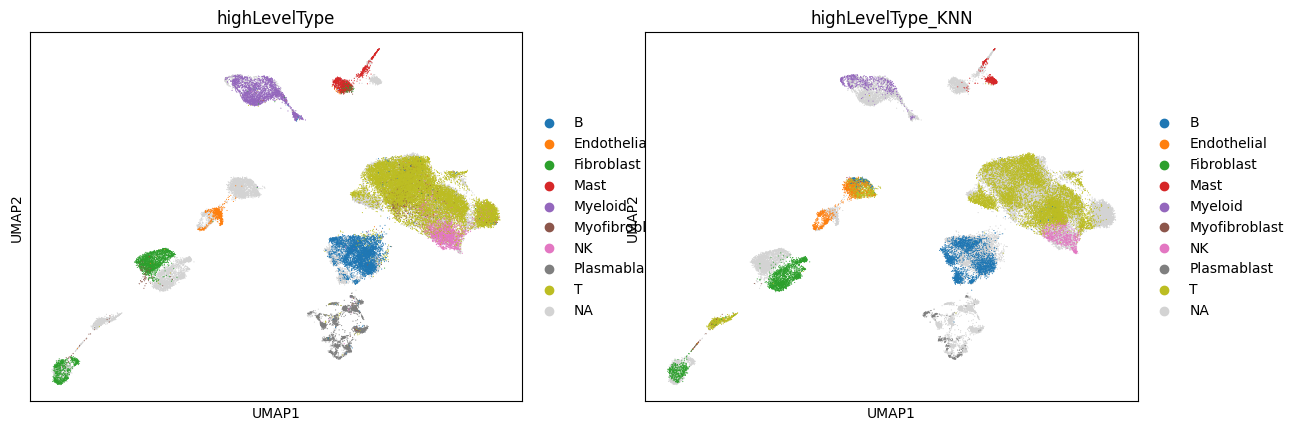

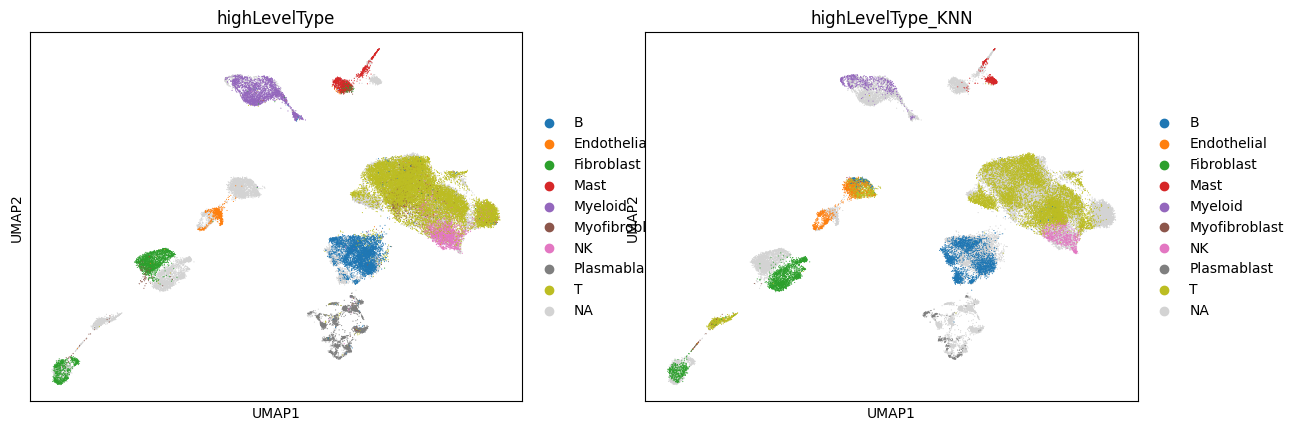


✅ Successfully generated cluster_membership.csv with 18616 test cell assignments.

--- First 5 rows of the generated cluster_membership.csv ---
                  index  cluster
0  AAACCCAAGGAGGCAG-1_5       58
1  AAACCCAAGTTGCGCC-1_5       58
2  AAACCCACACGGATCC-1_5       58
3  AAACCCACATCGGAAG-1_5       58
4  AAACCCAGTGCGAGTA-1_5       58


In [14]:
print(train_adata)
#per cell we have 7725 vars (gene intensity values),
#obs means each cell has one of these
#vars means each gene has one of these
#since we want for each cell to give it a grouping we look at the obs variables
# Sample, Patient, Tumor status, ngenes, n_genes_by_counts, total counts, total counts_mt, pct_counts_mt, highLevelType, chemo
print(test_adata)


AnnData object with n_obs × n_vars = 32374 × 7725
    obs: 'Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'highLevelType', 'chemo'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
AnnData object with n_obs × n_vars = 18616 × 7725
    obs: 'Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'chemo'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


--- Processing Training Data ---


2025-11-21 15:58:59,941 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


🔄 Applying HARMONY batch correction using key: 'Sample'...


2025-11-21 15:59:02,034 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-21 15:59:02,114 - harmonypy - INFO - Iteration 1 of 10
2025-11-21 15:59:06,297 - harmonypy - INFO - Iteration 2 of 10
2025-11-21 15:59:10,497 - harmonypy - INFO - Iteration 3 of 10
2025-11-21 15:59:14,667 - harmonypy - INFO - Iteration 4 of 10
2025-11-21 15:59:19,086 - harmonypy - INFO - Iteration 5 of 10
2025-11-21 15:59:22,713 - harmonypy - INFO - Converged after 5 iterations



🔍 Starting Grid Search...
   Metric=euclidean, Res=0.10 -> Clusters=7 -> Score=0.8053
   Metric=euclidean, Res=0.15 -> Clusters=7 -> Score=0.8053
   Metric=euclidean, Res=0.20 -> Clusters=9 -> Score=0.7132
   Metric=cosine, Res=0.10 -> Clusters=8 -> Score=0.8032
   Metric=cosine, Res=0.15 -> Clusters=10 -> Score=0.6969
   Metric=cosine, Res=0.20 -> Clusters=10 -> Score=0.6452

⭐ BEST RESULT FOUND: euclidean at res 0.15

--- Processing TEST set (Matching Train Logic) ---


2025-11-21 16:00:07,887 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


🔄 Applying HARMONY to Test Data...


2025-11-21 16:00:09,594 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-21 16:00:09,661 - harmonypy - INFO - Iteration 1 of 10
2025-11-21 16:00:11,552 - harmonypy - INFO - Iteration 2 of 10
2025-11-21 16:00:13,437 - harmonypy - INFO - Iteration 3 of 10
2025-11-21 16:00:15,316 - harmonypy - INFO - Iteration 4 of 10
2025-11-21 16:00:17,104 - harmonypy - INFO - Converged after 4 iterations


Test set cluster counts:
 leiden
0    5068
1    4564
2    2633
3    2260
4    2169
5     613
6     551
7     448
8     310
Name: count, dtype: int64

✅ cluster_membership.csv saved successfully.


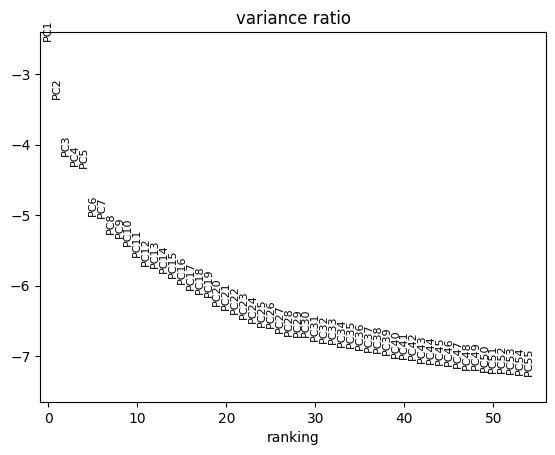

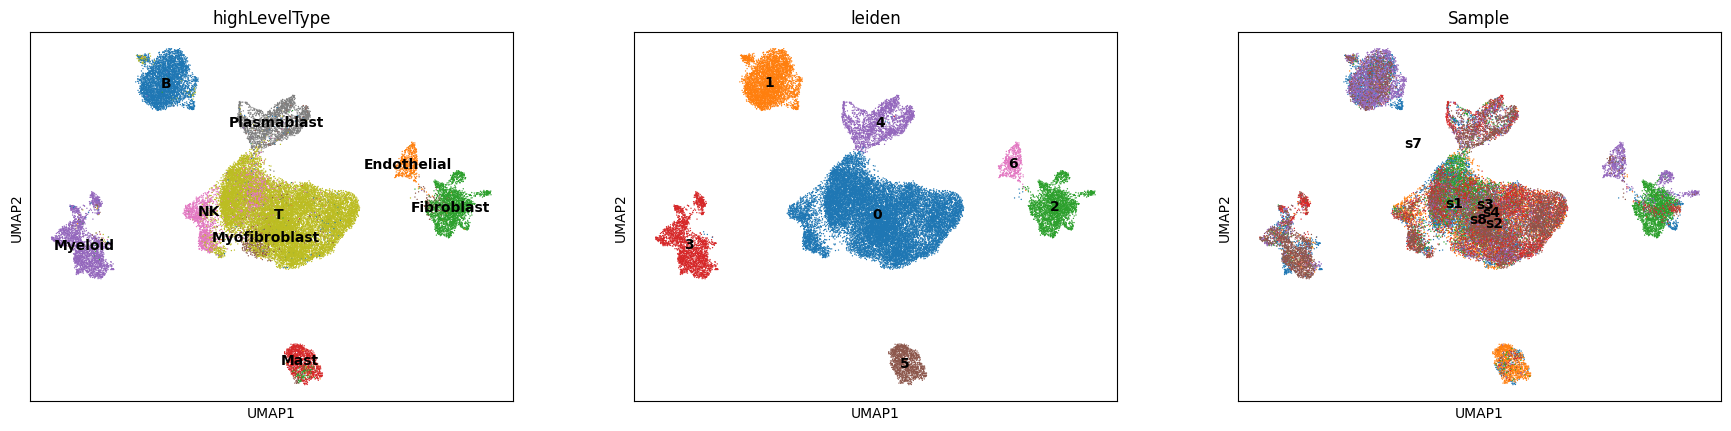

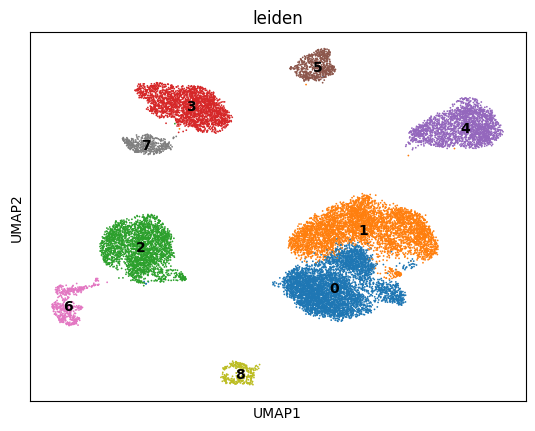

In [14]:

# =====================================================
# 1. Processing TRAIN data
# =====================================================
print("--- Processing Training Data ---")
ta = train_adata.copy()

# Ensure highLevelType is categorical
if 'highLevelType' in ta.obs:
    ta.obs['highLevelType'] = ta.obs['highLevelType'].astype('category')

# QC
sc.pp.calculate_qc_metrics(ta, inplace=True)

# STRATEGY 1: Identify HVGs (using raw counts required for seurat_v3)
target_genes = 3000
sc.pp.highly_variable_genes(ta, n_top_genes=target_genes, flavor='seurat_v3')

# Save the gene names for the Test set later
train_genes = ta.var_names[ta.var['highly_variable']]

# STRATEGY 2: Normalize & Log (Standard practice before scaling)
sc.pp.normalize_total(ta, target_sum=1e4)
sc.pp.log1p(ta)

# Slice to HVGs
ta = ta[:, train_genes].copy()

# Regression + scaling
# Note: consistently applied to both Train and Test
sc.pp.regress_out(ta, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(ta, max_value=10)

# PCA
sc.tl.pca(ta, n_comps=55, random_state=42) 

# Elbow Plot
sc.pl.pca_variance_ratio(ta, n_pcs=55, log=True, show=False)
#plt.savefig("pca_variance_ratio_elbow.png")

# =====================================================
# 2. Batch Correction (Harmony) - Train
# =====================================================
batch_key = 'Sample'
use_harmony = False

if batch_key in ta.obs and ta.obs[batch_key].nunique() > 1:
    print(f"🔄 Applying HARMONY batch correction using key: '{batch_key}'...")
    sc.external.pp.harmony_integrate(ta, key=batch_key, basis='X_pca', adjusted_basis='X_pca_harmony')
    use_harmony = True
else:
    print(f"ℹ️ Standard clustering (Batch key '{batch_key}' not found).")

# =====================================================
# 3. Grid Search: Metric + Resolution
# =====================================================
metrics_to_test = ['euclidean', 'cosine']
resolutions = [0.1, 0.15, 0.2] 
true_labels = ta.obs['highLevelType'].astype(str)

best_score = -1
best_params = {
    'metric': 'euclidean', 
    'resolution': resolutions[0]
}

results = [] 

print("\n🔍 Starting Grid Search...")

for metric in metrics_to_test:
    # Use consistent neighbor count (12)
    if use_harmony:
        sc.pp.neighbors(ta, n_neighbors=12, n_pcs=55, use_rep='X_pca_harmony', metric=metric)
    else:
        sc.pp.neighbors(ta, n_neighbors=12, n_pcs=55, metric=metric)

    for res in resolutions:
        key_name = f'leiden_{metric}_{res}'
        sc.tl.leiden(ta, resolution=res, key_added=key_name, random_state=42)
        
        pred = ta.obs[key_name].astype(str)
        n_clusters = len(ta.obs[key_name].unique())
        
        ari = adjusted_rand_score(true_labels, pred)
        v = v_measure_score(true_labels, pred)
        score = 0.5 * ari + 0.5 * v

        print(f"   Metric={metric}, Res={res:.2f} -> Clusters={n_clusters} -> Score={score:.4f}")
        results.append([metric, res, n_clusters, ari, v, score])

        if score > best_score:
            best_score = score
            best_params['metric'] = metric
            best_params['resolution'] = res

print(f"\n⭐ BEST RESULT FOUND: {best_params['metric']} at res {best_params['resolution']}")
pd.DataFrame(results).to_csv("training_clustering_gridsearch.csv", index=False)

# =====================================================
# 4. Finalize TRAIN Model
# =====================================================
# Re-run neighbors with best metric
if use_harmony:
    sc.pp.neighbors(ta, n_neighbors=12, n_pcs=55, use_rep='X_pca_harmony', metric=best_params['metric'])
else:
    sc.pp.neighbors(ta, n_neighbors=12, n_pcs=55, metric=best_params['metric'])

sc.tl.leiden(ta, resolution=best_params['resolution'], random_state=42)
ta.obs['best_cluster'] = ta.obs['leiden'].astype(int)

# UMAP
sc.tl.umap(ta, random_state=42)
sc.pl.umap(ta, color=['highLevelType', 'leiden', batch_key], legend_loc='on data', show=False)
#plt.savefig("umap_train_clusters.png")

cluster_df = pd.DataFrame({"cell_id": ta.obs_names, "cluster": ta.obs["best_cluster"].values})
#cluster_df.to_csv("train_cluster_assignments.csv", index=False)

# =====================================================
# 5. Apply to TEST set (STRICTLY MATCHING TRAIN)
# =====================================================
print(f"\n--- Processing TEST set (Matching Train Logic) ---")

ta_test = test_adata.copy()

# 1. Normalization & Log (Match Train)
sc.pp.normalize_total(ta_test, target_sum=1e4)
sc.pp.log1p(ta_test)

# 2. Filter Genes: Must match Train HVGs EXACTLY
# We find the intersection of genes to avoid errors if some are missing in test
common_genes = list(set(train_genes) & set(ta_test.var_names))
ta_test = ta_test[:, common_genes].copy()

# Zero-pad if any training genes were missing in test (rare but possible)
if len(common_genes) < len(train_genes):
    print("⚠️ Warning: Some training genes missing in test set. Zero-padding...")
    # Logic to add missing genes would go here, but usually intersection is fine 
    # provided the bulk of genes are present.

# 3. Regression & Scaling (Match Train)
# Note: we use the same params (total_counts, pct_counts_mt)
sc.pp.calculate_qc_metrics(ta_test, inplace=True) 
sc.pp.regress_out(ta_test, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(ta_test, max_value=10)

# 4. PCA (Match Train n_comps=55)
sc.tl.pca(ta_test, n_comps=55, random_state=42)

# 5. Batch Correction / Neighbors (Match Train)
if batch_key in ta_test.obs and ta_test.obs[batch_key].nunique() > 1:
    print(f"🔄 Applying HARMONY to Test Data...")
    sc.external.pp.harmony_integrate(ta_test, key=batch_key, basis='X_pca', adjusted_basis='X_pca_harmony')
    sc.pp.neighbors(ta_test, n_neighbors=12, n_pcs=55, use_rep='X_pca_harmony', metric=best_params['metric'])
else:
    sc.pp.neighbors(ta_test, n_neighbors=12, n_pcs=55, metric=best_params['metric'])

# 6. UMAP & Leiden
sc.tl.umap(ta_test, random_state=42)
sc.tl.leiden(ta_test, resolution=best_params['resolution'], random_state=42)

# Submission
n_cells = ta_test.n_obs
cluster_labels = pd.DataFrame({
    "index": ta_test.obs_names,
    "cluster": ta_test.obs["leiden"].astype(int).values + 1 #1-indexed
})

print("Test set cluster counts:\n", ta_test.obs['leiden'].value_counts())
sc.pl.umap(ta_test, color='leiden', legend_loc='on data', show=False)
plt.savefig("umap_test_clusters.png")

cluster_labels.to_csv("cluster_membership.csv", index=False)
print("\n✅ cluster_membership.csv saved successfully.")

## tree regression approach 

In [ ]:
from sklearn.model_selection import train_test_split
all_cells = train_adata.obs_names.to_list()
train_cells, test_cells  = train_test_split(all_cells, test_size=0.2, random_state=10)
s_adata_train = train_adata[train_cells, :].copy()
s_adata_test = train_adata[test_cells, :].copy()



<class 'scipy.sparse._csr.csr_matrix'>


##  approach by ferdinand

In [6]:
# =========================
# Limit CPU / PyTorch threads
# =========================
import os
import torch
import numpy as np
import scanpy as sc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import adjusted_rand_score, v_measure_score
from scvi.model import SCVI, SCANVI



# =========================
# Group setup
# =========================
train_adata.obs["dataset_type"] = "Train"
test_adata.obs["dataset_type"] = "Test"

adata = sc.concat([train_adata, test_adata], label="batch_split", join="outer", merge="same")

train_mask = adata.obs["dataset_type"] == "Train"
groups_train = adata.obs.loc[train_mask, "Sample"].values
y_train_full = adata.obs.loc[train_mask, "highLevelType"].astype("category")

unique_samples = np.unique(groups_train)
n_splits = len(unique_samples)

gkf = GroupKFold(n_splits=n_splits)
adata_train = adata[train_mask].copy()

sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=2000, 
    subset=True, 
    flavor="seurat_v3",
    batch_key="Sample"
)

# =========================
# Function to train SCANVI for a fold
# =========================
def train_scANVI_fold(adata_fold, n_latent=20, n_hidden=128, n_layers=2, dropout_rate=0.2, n_samples_per_label=50):
    # Setup AnnData
    SCVI.setup_anndata(
        adata_fold,
        labels_key='label_scANVI',
        batch_key='Sample'
    )

    # Initialize SCVI
    scvi_model = SCVI(
        adata_fold,
        n_latent=n_latent,
        n_hidden=n_hidden,
        n_layers=n_layers,
        dropout_rate=dropout_rate
    )

    # Train SCVI
    scvi_model.train(
        max_epochs=100,
        early_stopping=True,
        early_stopping_patience=5,
        accelerator="mps",  # or "cpu"
        devices=1
    )

    # Convert to SCANVI with upsampling
    scanvi_model = SCANVI.from_scvi_model(
        scvi_model,
        labels_key="label_scANVI",
        unlabeled_category="Unknown",
        n_samples_per_label=n_samples_per_label
    )

    scanvi_model.train(
        max_epochs=20,
        early_stopping=True,
        early_stopping_patience=5
    )

    return scanvi_model

# =========================
# Cross-Validation Loop
# =========================
fold_results = []

print(f"=== LOOCV START (scANVI) — {n_splits} folds ===")

# Example hyperparameters (you can modify these for testing)
hyperparams = {
    "n_latent": 20,
    "n_hidden": 128,
    "n_layers": 2,
    "dropout_rate": 0.2,
    "n_samples_per_label": 50
}

for fold_id, (train_idx, val_idx) in enumerate(gkf.split(np.zeros(len(groups_train)), y_train_full, groups_train), start=1):
    print(f"\n======================")
    print(f"Fold {fold_id} / {n_splits}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
    print("======================")

    # Subset AnnData for this fold
    adata_fold_train = adata_train[train_idx].copy()
    adata_fold_val = adata_train[val_idx].copy()

    # Prepare labels for scANVI
    adata_fold_train.obs["label_scANVI"] = adata_fold_train.obs["highLevelType"].astype("category")
    adata_fold_val.obs["label_scANVI"] = "Unknown"

    # Merge train + validation
    adata_fold = sc.concat([adata_fold_train, adata_fold_val], axis=0)
    adata_fold.obs["label_scANVI"] = adata_fold.obs["label_scANVI"].astype("category")
    if "Unknown" not in adata_fold.obs["label_scANVI"].cat.categories:
        adata_fold.obs["label_scANVI"] = adata_fold.obs["label_scANVI"].cat.add_categories(["Unknown"])

    adata_fold.obs['Sample'] = adata_fold.obs['Sample'].astype(str).astype('category')

    # Train SCANVI with hyperparameters
    scanvi_model = train_scANVI_fold(adata_fold, **hyperparams)

    # Predict on validation fold
    y_pred = scanvi_model.predict(adata_fold_val)
    y_true = adata_fold_val.obs["highLevelType"].astype(str)

    # Metrics
    ari = adjusted_rand_score(y_true, y_pred)
    vms = v_measure_score(y_true, y_pred)
    print(f"Fold {fold_id} → ARI={ari:.4f}, VMS={vms:.4f}")

    fold_results.append({"fold": fold_id, "ari": ari, "v_measure": vms})

# =========================
# Summary
# =========================
print("\n=== Cross-Validation Results ===")
for r in fold_results:
    print(f"Fold {r['fold']}: ARI={r['ari']:.4f}, VMS={r['v_measure']:.4f}")

print("\nMean:")
print("ARI:", np.mean([r["ari"] for r in fold_results]))
print("VMS:", np.mean([r["v_measure"] for r in fold_results]))

=== LOOCV START (scANVI) — 6 folds ===

Fold 1 / 6
Train samples: 25553, Val samples: 6821


/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/da

Epoch 1/100:   0%|          | 0/100 [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Exception raised during training. <class 'NameError'> 1


SystemExit: 1

/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/scvi/__init__.py
<class 'scvi.model._scvi.SCVI'> <class 'scvi.model._scanvi.SCANVI'>


In [13]:
!pip cache purge

Files removed: 551 (237.3 MB)


In [14]:
!pip install scvi-tools --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 628.9/628.9 kB 14.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [scvi-tools]9 [scvi-tools]


In [ ]:
import sys
print(sys.executable)
import scvi
print(scvi.__file__)
!pip list | grep scvi
import importlib
import scvi
importlib.reload(scvi)
from scvi.model import SCVI, SCANVI
print(SCVI)

/Users/samuelgair/miniforge3/envs/scanpy-env/bin/python
None
scvi-tools              1.4.0.post1


ImportError: cannot import name 'settings' from 'scvi' (unknown location)

In [ ]:
# =========================
# Limit CPU / PyTorch threads
# =========================
import os
import torch
import numpy as np
import scanpy as sc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import adjusted_rand_score, v_measure_score
from scvi.model import SCVI, SCANVI

# CPU thread limits
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

torch.set_num_threads(1)
RuntimeError                              Traceback (most recent call last)
Cell In[4], line 19
     16 os.environ["NUMEXPR_NUM_THREADS"] = "1"
     18 torch.set_num_threads(1)
---> 19 torch.set_num_interop_threads(1)
     21 # =========================
     22 # Group setup
     23 # =========================
     24 train_adata.obs["dataset_type"] = "Train"

RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads calledRuntimeError                              Traceback (most recent call last)
Cell In[4], line 19
     16 os.environ["NUMEXPR_NUM_THREADS"] = "1"
     18 torch.set_num_threads(1)
---> 19 torch.set_num_interop_threads(1)
     21 # =========================
     22 # Group setup
     23 # =========================
     24 train_adata.obs["dataset_type"] = "Train"

RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called

# =========================
# Group setup
# =========================
train_adata.obs["dataset_type"] = "Train"
test_adata.obs["dataset_type"] = "Test"

adata = sc.concat([train_adata, test_adata], label="batch_split", join="outer", merge="same")

train_mask = adata.obs["dataset_type"] == "Train"
groups_train = adata.obs.loc[train_mask, "Sample"].values
y_train_full = adata.obs.loc[train_mask, "highLevelType"].astype("category")

unique_samples = np.unique(groups_train)
n_splits = len(unique_samples)

gkf = GroupKFold(n_splits=n_splits)
adata_train = adata[train_mask].copy()

sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=2000, 
    subset=True, 
    flavor="seurat_v3",
    batch_key="Sample"
)

# =========================
# Function to train SCANVI for a fold
# =========================
def train_scANVI_fold(adata_fold, n_latent=20, n_hidden=128, n_layers=2, dropout_rate=0.2, n_samples_per_label=50):
    # Setup AnnData
    SCVI.setup_anndata(
        adata_fold,
        labels_key='label_scANVI',
        batch_key='Sample'
    )

    # Initialize SCVI
    scvi_model = SCVI(
        adata_fold,
        n_latent=n_latent,
        n_hidden=n_hidden,
        n_layers=n_layers,
        dropout_rate=dropout_rate
    )

    # Train SCVI
    scvi_model.train(
        max_epochs=100,
        early_stopping=True,
        early_stopping_patience=5,
        accelerator="mps",  # or "cpu"
        devices=1
    )

    # Convert to SCANVI with upsampling
    scanvi_model = SCANVI.from_scvi_model(
        scvi_model,
        labels_key="label_scANVI",
        unlabeled_category="Unknown",
        n_samples_per_label=n_samples_per_label
    )

    scanvi_model.train(
        max_epochs=20,
        early_stopping=True,
        early_stopping_patience=5
    )

    return scanvi_model

# =========================
# Cross-Validation Loop
# =========================
fold_results = []

print(f"=== LOOCV START (scANVI) — {n_splits} folds ===")

# Example hyperparameters (you can modify these for testing)
hyperparams = {
    "n_latent": 20,
    "n_hidden": 128,
    "n_layers": 2,
    "dropout_rate": 0.2,
    "n_samples_per_label": 50
}

for fold_id, (train_idx, val_idx) in enumerate(gkf.split(np.zeros(len(groups_train)), y_train_full, groups_train), start=1):
    print(f"\n======================")
    print(f"Fold {fold_id} / {n_splits}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
    print("======================")

    # Subset AnnData for this fold
    adata_fold_train = adata_train[train_idx].copy()
    adata_fold_val = adata_train[val_idx].copy()

    # Prepare labels for scANVI
    adata_fold_train.obs["label_scANVI"] = adata_fold_train.obs["highLevelType"].astype("category")
    adata_fold_val.obs["label_scANVI"] = "Unknown"

    # Merge train + validation
    adata_fold = sc.concat([adata_fold_train, adata_fold_val], axis=0)
    adata_fold.obs["label_scANVI"] = adata_fold.obs["label_scANVI"].astype("category")
    if "Unknown" not in adata_fold.obs["label_scANVI"].cat.categories:
        adata_fold.obs["label_scANVI"] = adata_fold.obs["label_scANVI"].cat.add_categories(["Unknown"])

    adata_fold.obs['Sample'] = adata_fold.obs['Sample'].astype(str).astype('category')

    # Train SCANVI with hyperparameters
    scanvi_model = train_scANVI_fold(adata_fold, **hyperparams)

    # Predict on validation fold
    y_pred = scanvi_model.predict(adata_fold_val)
    y_true = adata_fold_val.obs["highLevelType"].astype(str)

    # Metrics
    ari = adjusted_rand_score(y_true, y_pred)
    vms = v_measure_score(y_true, y_pred)
    print(f"Fold {fold_id} → ARI={ari:.4f}, VMS={vms:.4f}")

    fold_results.append({"fold": fold_id, "ari": ari, "v_measure": vms})

# =========================
# Summary
# =========================
print("\n=== Cross-Validation Results ===")
for r in fold_results:
    print(f"Fold {r['fold']}: ARI={r['ari']:.4f}, VMS={r['v_measure']:.4f}")

print("\nMean:")
print("ARI:", np.mean([r["ari"] for r in fold_results]))
print("VMS:", np.mean([r["v_measure"] for r in fold_results]))

RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called

In [ ]:
# run in your env / notebook
import scvi, sys, importlib
print("scvi.__file__:", getattr(scvi, "__file__", None))
print("scvi.__package__:", getattr(scvi, "__package__", None))
print("scvi.__version__:", getattr(scvi, "__version__", None))
print("sys.executable:", sys.executable)
print("importlib.find_spec('scvi'):", importlib.util.find_spec("scvi")) 

scvi.__file__: /Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/scvi/__init__.py
scvi.__package__: scvi
scvi.__version__: 0.6.8
sys.executable: /Users/samuelgair/miniforge3/envs/scanpy-env/bin/python
importlib.find_spec('scvi'): ModuleSpec(name='scvi', loader=<_frozen_importlib_external.SourceFileLoader object at 0x105116a50>, origin='/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/scvi/__init__.py', submodule_search_locations=['/Users/samuelgair/miniforge3/envs/scanpy-env/lib/python3.12/site-packages/scvi'])


# Step 3: Save the required files

In [ ]:
# pred_props should be a DataFrame containing the estimated cell type proportions for the patients in all_bulkified
# pred_props.columns = ['index','s5_0','s5_1',...,'s10_3','s10_4'] = np.append(["index"],all_bulkified.columns)
# pred_props['index'] = ['T', 'Endothelial', 'Fibroblast', 'Plasmablast', 'B', 'Myofibroblast',
#       'NK', 'Myeloid', 'Mast']


In [27]:
results_path = pl.Path("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/results")
cluster_labels = pd.read_csv("/Users/samuelgair/Desktop/ml4G/ML4G_Project_2_Data/cluster_membership.csv")
#results_path = pl.Path("/Users/ferdinandunterhuber/Documents/Studium/Master/ML for Genomics/Project 2")

In [22]:
assert all(pred_props_for_save.columns == np.append(["index"],test_bulk.columns)), "Wrong columns"

In [23]:
assert all(pred_props_for_save['index']== ['T', 'Endothelial', 'Fibroblast', 'Plasmablast', 'B', 'Myofibroblast',
       'NK', 'Myeloid', 'Mast']), "Wrong order for cell types"

In [24]:
assert all(pred_props_for_save.drop("index",axis=1).sum().round()==1), "The proportions for a single patient must sum to 1"

In [28]:
print(cluster_labels.columns)

Index(['index', 'cluster'], dtype='object')


In [29]:
assert all(cluster_labels.columns == ["index", "cluster"]), "Wrong columns"

In [30]:
assert all(cluster_labels["index"] == test_adata.obs_names), "The cell ids are either not all present or not in the right order"

In [32]:
import zipfile

archive_name = "Gair_Samuel_Project2.zip" # TODO
#archive_name = "Unterhuber_Ferdinand_Project2.zip"

with zipfile.ZipFile(results_path / archive_name, "x") as zf:
    with zf.open(f"pred_props.csv", "w") as buffer:
        pred_props_for_save.to_csv(buffer)
    with zf.open(f"cluster_membership.csv", "w") as buffer:
        cluster_labels.to_csv(buffer)
    zf.close()